# Day 2 - EDA and Hypothesis Tests

Building on the Day 1 data quality findings, this notebook tests two hypotheses about what drives customer trust loss on the Olist marketplace.

## Hypotheses

**H1.** The delivery promise gap (estimated delivery date minus actual delivery date) drives review scores more than product category does. If true, customer satisfaction is primarily a logistics problem, not a product problem.

**H2.** A small number of seller-state to customer-state routes account for a disproportionate share of late deliveries. If true, the logistics problem is concentrated in specific lanes, not system-wide.

Each hypothesis includes a falsification test, an analysis whose result would prove the hypothesis wrong rather than only confirming it.

These findings feed directly into the Day 3 Seller Trust Score.

## DQ findings applied below

Per Day 1's `01_data_quality.ipynb`:

- Use `customer_unique_id` for any per-customer aggregation (not `customer_id`).
- Filter orders to `order_purchase_timestamp` between 2016-09-04 and 2018-10-17.
- Collapse `geolocation` to one row per zip prefix (median lat/lng).
- Tag null product categories as "unknown".
- Treat null `order_delivered_customer_date` as undelivered, not missing data.


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import get_engine

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
sns.set_palette("Set2")

engine = get_engine()

# SQLite stores datetimes as TEXT, so re-parse on read.
DATE_COLS = {
    "orders": [
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "order_items": ["shipping_limit_date"],
    "order_reviews": ["review_creation_date", "review_answer_timestamp"],
}

def load(table):
    return pd.read_sql(f"SELECT * FROM {table}", engine, parse_dates=DATE_COLS.get(table))

orders        = load("orders")
order_items   = load("order_items")
order_reviews = load("order_reviews")
products      = load("products")
sellers       = load("sellers")
customers     = load("customers")
geolocation   = load("geolocation")
categories    = load("product_category_name_translation")

# Filter orders to the operating window from Day 1 findings.
WINDOW_START = pd.Timestamp("2016-09-04")
WINDOW_END   = pd.Timestamp("2018-10-17")
orders = orders[
    (orders["order_purchase_timestamp"] >= WINDOW_START)
    & (orders["order_purchase_timestamp"] <= WINDOW_END)
].copy()

# Tag null product categories as "unknown".
products["product_category_name"] = products["product_category_name"].fillna("unknown")

# Collapse geolocation to one row per zip prefix (median lat/lng + modal state).
geo = (geolocation
       .groupby("geolocation_zip_code_prefix", as_index=False)
       .agg(lat=("geolocation_lat", "median"),
            lng=("geolocation_lng", "median"),
            state=("geolocation_state", lambda s: s.mode().iloc[0])))

print(f"orders (windowed):     {len(orders):,}")
print(f"order_items:           {len(order_items):,}")
print(f"order_reviews:         {len(order_reviews):,}")
print(f"products:              {len(products):,}")
print(f"sellers:               {len(sellers):,}")
print(f"customers:             {len(customers):,}")
print(f"geolocation collapsed: {len(geo):,} unique zip prefixes (from {len(geolocation):,} rows)")


orders (windowed):     99,440
order_items:           112,650
order_reviews:         99,224
products:              32,951
sellers:               3,095
customers:             99,441
geolocation collapsed: 19,015 unique zip prefixes (from 1,000,163 rows)


## Building the analysis dataframe

I need a denormalised table with one row per (order, item) pair, plus the columns the hypothesis tests will use. Joining orders, order_items, products, sellers, customers, order_reviews, and the English category translation.

Day 1 found that 6 of 7 FK relationships are clean. The exception is `products.product_category_name` to `product_category_name_translation` (2 orphan keys, 13 rows). LEFT JOIN there keeps those 13 rows visible.

Two derived columns get added:

- `promise_gap_days` = estimated delivery date minus actual delivery date. Positive means delivered early. Null when the order was never delivered.
- `actual_delivery_days` = actual delivery date minus purchase date. Null when not delivered.


In [2]:
# One review per order. Day 1 found review_id is not unique across orders, so
# take the earliest review per order to be deterministic.
review_by_order = (order_reviews
                   .sort_values("review_creation_date")
                   .drop_duplicates("order_id", keep="first")
                   [["order_id", "review_score", "review_creation_date"]])

base = (orders
        .merge(customers, on="customer_id", how="left")
        .merge(review_by_order, on="order_id", how="left"))

# Order-item rows: one row per item, multi-item orders fan out.
analysis_df = (order_items
               .merge(base, on="order_id", how="inner")
               .merge(sellers, on="seller_id", how="left")
               .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
               .merge(categories, on="product_category_name", how="left"))

# Promise gap: positive means delivered early, negative means delivered late.
# Naturally null for undelivered orders.
analysis_df["promise_gap_days"] = (
    analysis_df["order_estimated_delivery_date"] - analysis_df["order_delivered_customer_date"]
).dt.days

# Actual delivery time, from purchase to receipt.
analysis_df["actual_delivery_days"] = (
    analysis_df["order_delivered_customer_date"] - analysis_df["order_purchase_timestamp"]
).dt.days

# English category, falling back to Portuguese where translation is missing.
analysis_df["category_en"] = analysis_df["product_category_name_english"].fillna(
    analysis_df["product_category_name"]
)

delivered_count = analysis_df["order_delivered_customer_date"].notna().sum()
print(f"analysis_df shape: {analysis_df.shape}")
print(f"rows with reviews:  {analysis_df['review_score'].notna().sum():,} of {len(analysis_df):,} ({analysis_df['review_score'].notna().mean():.1%})")
print(f"rows delivered:     {delivered_count:,} ({delivered_count/len(analysis_df):.1%})")


analysis_df shape: (112650, 28)
rows with reviews:  111,708 of 112,650 (99.2%)
rows delivered:     110,196 (97.8%)


## 1. Sanity baseline

Three charts before any hypothesis claim. Confirms the data looks sensible and gives context for the tests that follow.


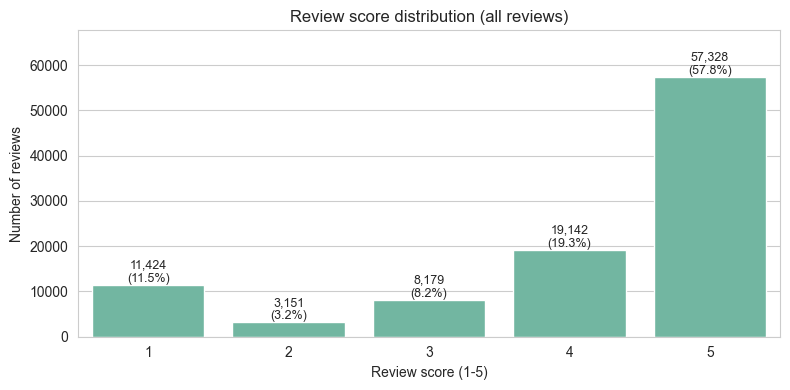

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
review_counts = order_reviews["review_score"].value_counts().sort_index()
sns.barplot(x=review_counts.index, y=review_counts.values, ax=ax)
ax.set_xlabel("Review score (1-5)")
ax.set_ylabel("Number of reviews")
ax.set_title("Review score distribution (all reviews)")
total = review_counts.sum()
for i, v in enumerate(review_counts.values):
    ax.text(i, v, f"{v:,}\n({v/total:.1%})", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, review_counts.max() * 1.18)
plt.tight_layout()
plt.show()


**Review distribution.** Strongly U-shaped. 5-star reviews dominate at 57.8%, but 1-star is the second most common at 11.5%, more than 3-star (8.2%) or 2-star (3.2%). 4-star fills out the rest at 19.3%. People who write reviews tend to be at the extremes: very satisfied or very upset. Middle-of-the-road experiences mostly go unreviewed. This shape makes 1-star reviews a meaningful and noisy signal of trust loss, which is what the hypothesis tests below will exploit.


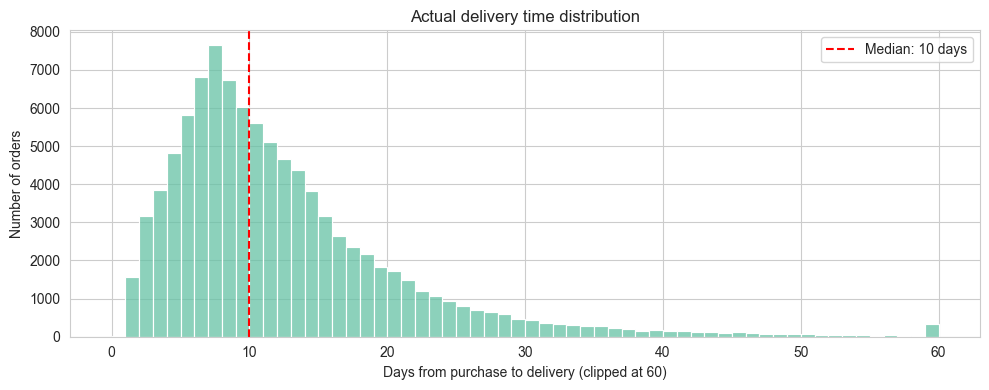

Median delivery time:   10 days
Mean delivery time:     12.1 days
95th percentile:        29 days
Max:                    209 days


In [4]:
delivered_orders = orders[orders["order_delivered_customer_date"].notna()].copy()
delivered_orders["delivery_days"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]
).dt.days

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(delivered_orders["delivery_days"].clip(0, 60), bins=60, ax=ax)
ax.set_xlabel("Days from purchase to delivery (clipped at 60)")
ax.set_ylabel("Number of orders")
ax.set_title("Actual delivery time distribution")
median_days = delivered_orders["delivery_days"].median()
ax.axvline(median_days, color="red", linestyle="--", label=f"Median: {median_days:.0f} days")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median delivery time:   {median_days:.0f} days")
print(f"Mean delivery time:     {delivered_orders['delivery_days'].mean():.1f} days")
print(f"95th percentile:        {delivered_orders['delivery_days'].quantile(0.95):.0f} days")
print(f"Max:                    {delivered_orders['delivery_days'].max():.0f} days")


**Delivery time distribution.** Median 10 days, mean 12.1 days, 95th percentile 29 days. The distribution is right-skewed with a long tail (max 209 days). The skew is the story: most orders arrive in a fortnight, but the worst-case tail extends to 6+ months. Day 2's hypotheses are about that tail, not the median.


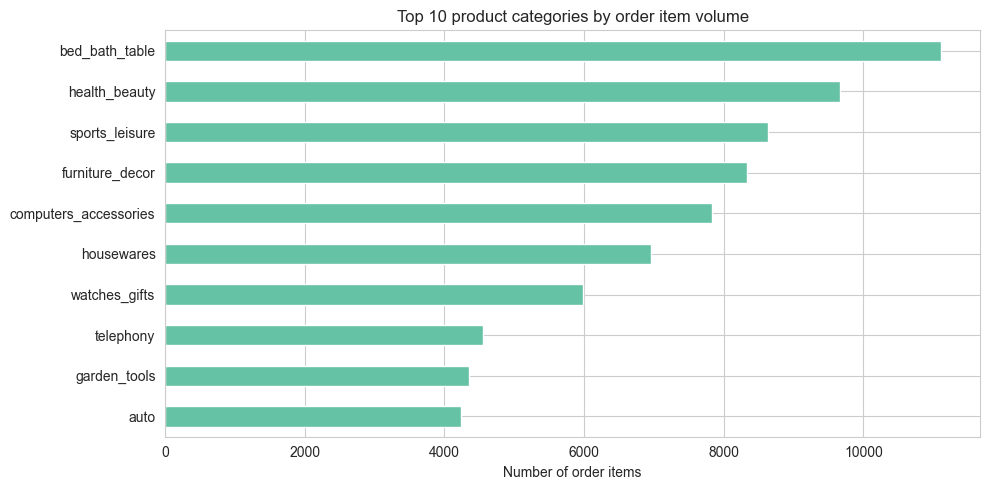

Top 10 categories cover 63.6% of all order items
Total distinct categories: 74


In [5]:
top_categories = (analysis_df
                  .groupby("category_en")
                  .size()
                  .sort_values(ascending=False)
                  .head(10))

fig, ax = plt.subplots(figsize=(10, 5))
top_categories.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of order items")
ax.set_ylabel("")
ax.set_title("Top 10 product categories by order item volume")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Top 10 categories cover {top_categories.sum() / len(analysis_df):.1%} of all order items")
print(f"Total distinct categories: {analysis_df['category_en'].nunique()}")


**Category mix.** 74 distinct categories, but the top 10 cover 63.6% of order items. Heavy concentration in `bed_bath_table`, `health_beauty`, `sports_leisure`, and `furniture_decor`. Any category-level finding will be dominated by these few categories, which means a category-vs-delivery comparison must use weighted averages or stratify by volume to be honest.
